# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown

In [2]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

Ray module not found. Multiprocessing features are not available


True

In [3]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)


# Creation of the model

In [4]:
#Benchmark1
highfid = lambda x: (6.*x/5-2.)**2*np.sin(12.*x/5-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x/5-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

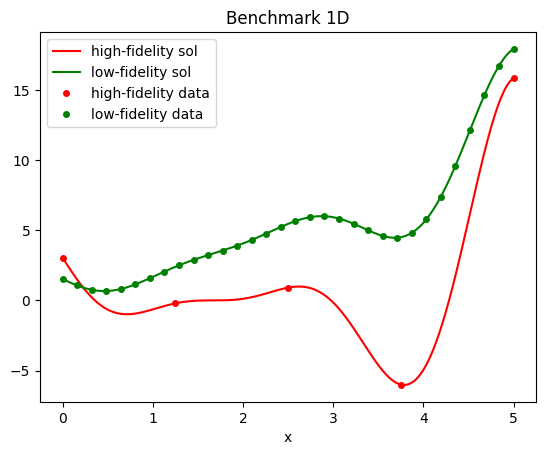

In [5]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model




The function training took 6.4814441204071045 seconds.


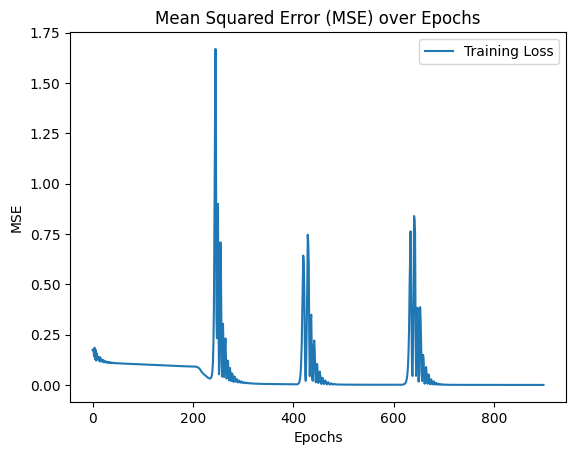

Test MSE: 59.6035932808948
R^2: -2985.2446807896326


In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R2_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 3.567277431488037 seconds.


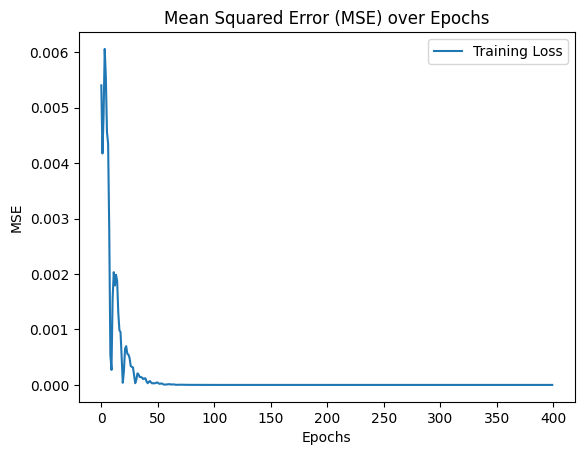

Test MSE: 63.291285540817064
R^2: -3170.0045381976224


In [7]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R2_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 6.893387079238892 seconds.


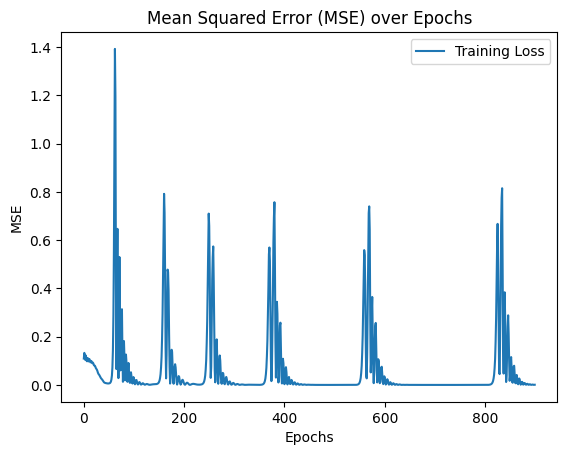

The function training took 3.0085623264312744 seconds.


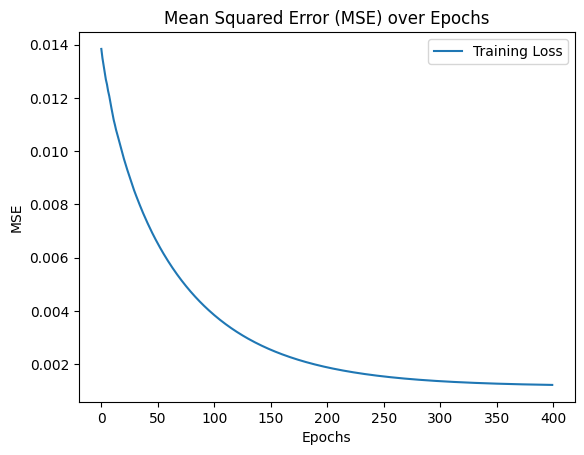

Test MSE: 41.037260792408915
R^2: -2055.0388226591886


In [8]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R2_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

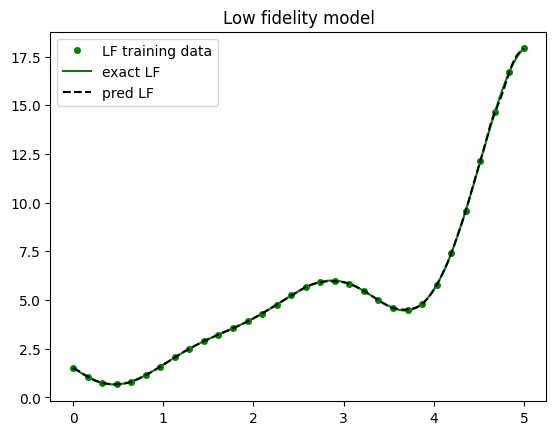

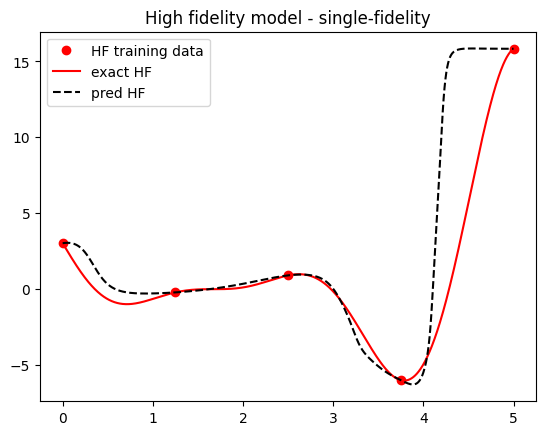

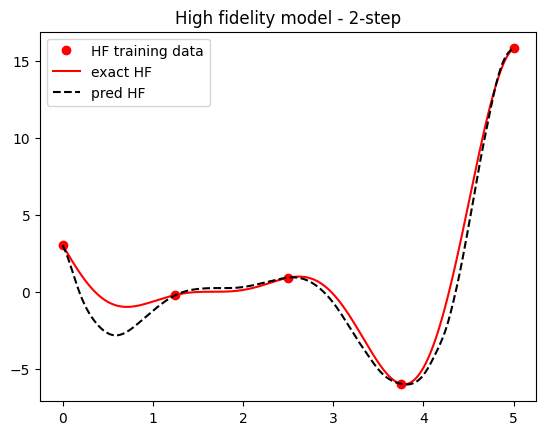

In [9]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using CuqiPy

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3,4.8])
mean_prior = np.ones(dim)*2.5
sigma=[0.5,1,1.5,2]
sigma_noise=0.1
#rwmh_cov = np.eye(len(real_x)) # !
scale=0.1
iterations =1000
burnin = 550
n_chains=5

Sample 1000 / 1000

Average acceptance rate: 0.1288888888888889 

********************  # Mean values = [0.23653805 1.58688259 0.19494201 2.537717  ]  ********************
Sample 1000 / 1000

Average acceptance rate: 0.0044444444444444444 

********************  # Mean values = [0.24348818 1.44655441 0.18481005 1.27097934]  ********************
Sample 1000 / 1000

Average acceptance rate: 0.0044444444444444444 

********************  # Mean values = [0.53318581 1.02830966 0.18642089 0.84865121]  ********************
Sample 1000 / 1000

Average acceptance rate: 0.008888888888888889 

********************  # Mean values = [0.44923881 1.09396881 0.49787621 0.63714209]  ********************
Sample 990 / 1000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 1000 / 1000

Average acceptance rate: 0.0044444444444444444 

********************  # Mean values = [0.39861523 0.92339274 0.43532064 0.51010145]  ********************
(5, 4, 450)


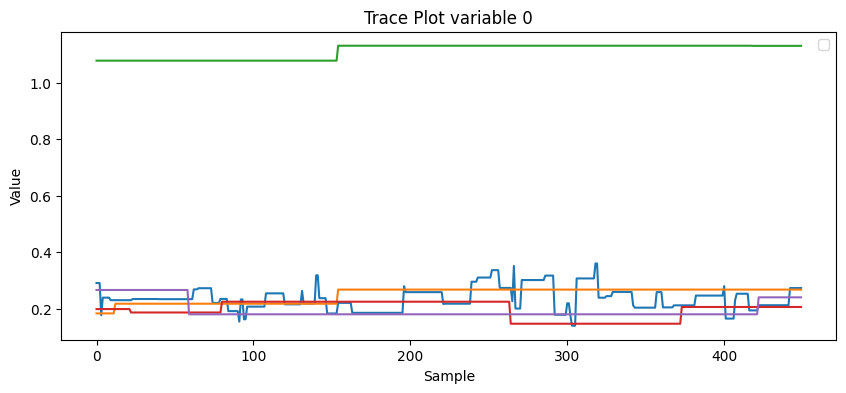

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


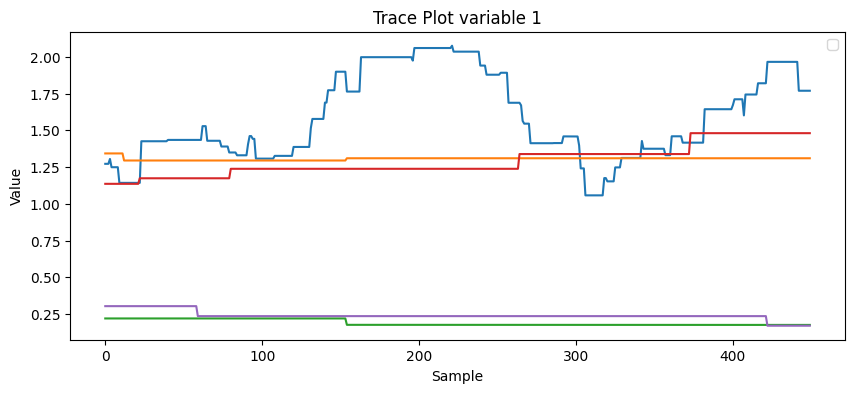

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


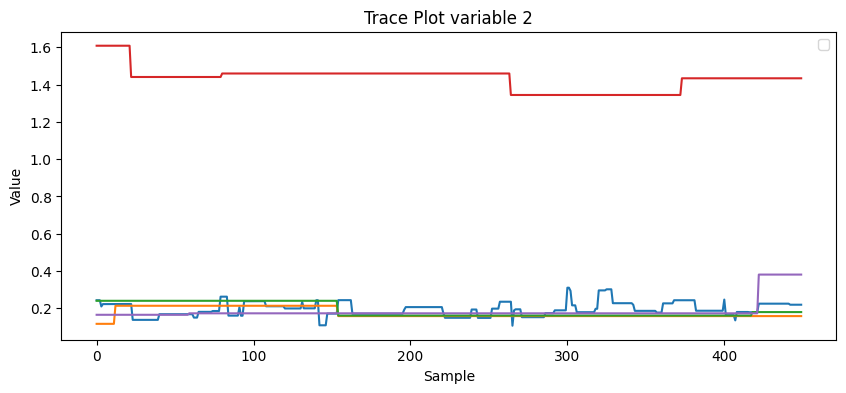

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


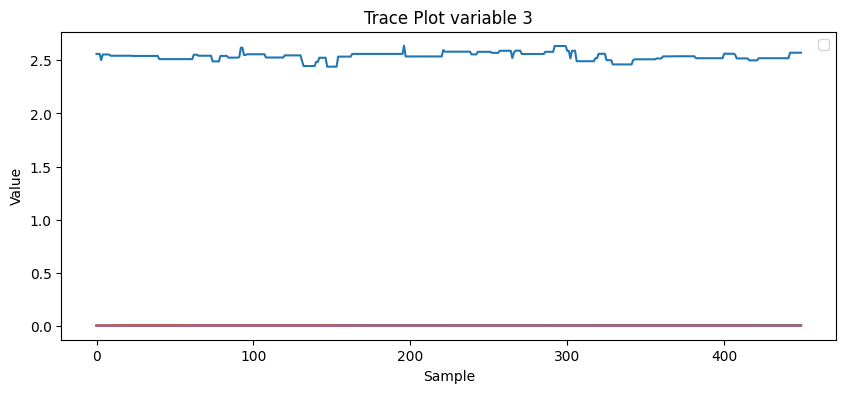

[0.95777778 0.64711111 0.30888889 0.05644444 0.01377778 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.07377778 0.13155556]


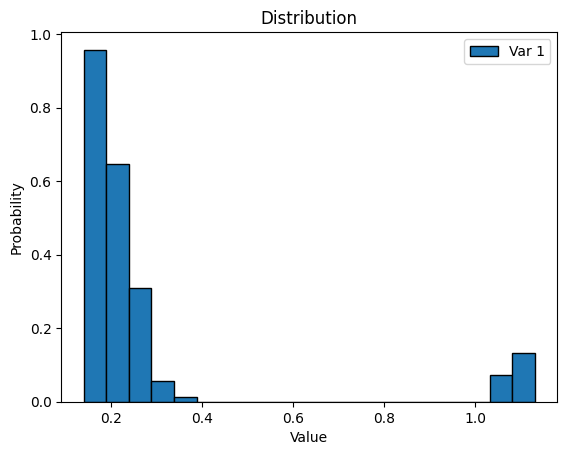

[1.37777778 0.22888889 0.01244444 0.         0.         0.
 0.         0.         0.         0.07377778 0.17644444 0.29466667
 0.12888889 0.22266667 0.00755556 0.02355556 0.016      0.00666667
 0.01644444 0.03333333]


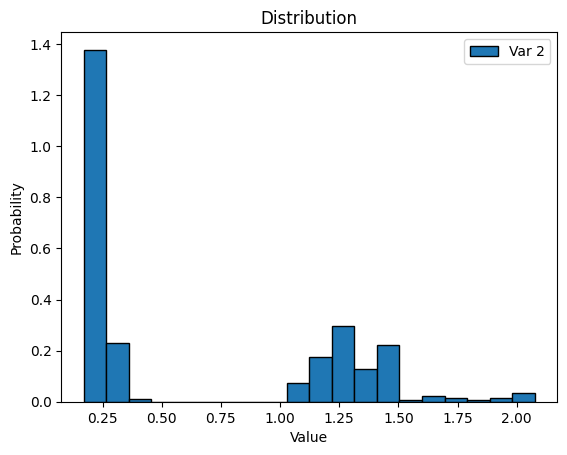

[0.90444444 0.83333333 0.24622222 0.016      0.         0.
 0.         0.         0.         0.         0.         0.
 0.07377778 0.14977778 0.02666667 0.15733333 0.25822222 0.10711111
 0.12533333 0.016     ]


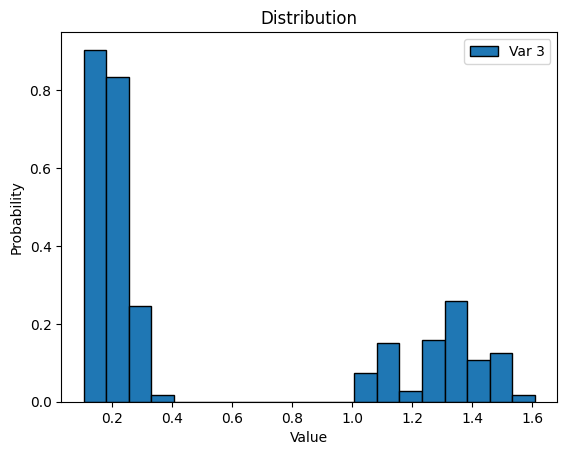

[0.808      1.75066667 0.24133333 0.         0.         0.
 0.         0.         0.25022222 0.29466667 0.22711111 0.132
 0.02622222 0.016      0.02044444 0.03333333 0.         0.
 0.02666667 0.17333333]


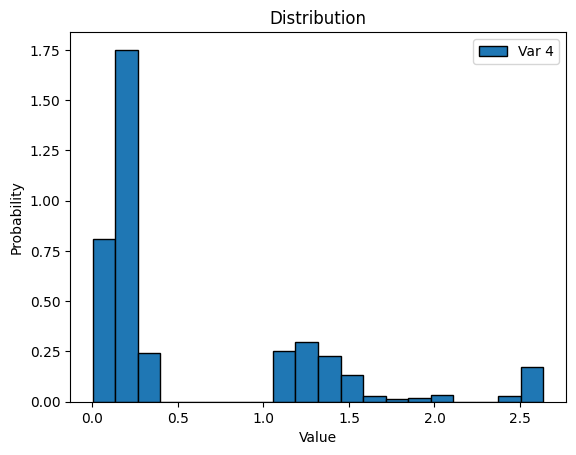

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 6.850027575527872  ********************


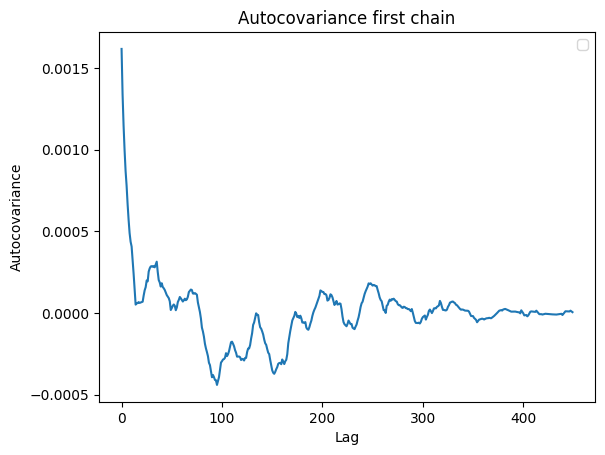

the difference between estimated values [0.60138477 1.07660726 2.56467936 4.28989855]
 the difference between outputs of two models are [ 0.97821736  1.92894053  1.72060955 16.07504821]


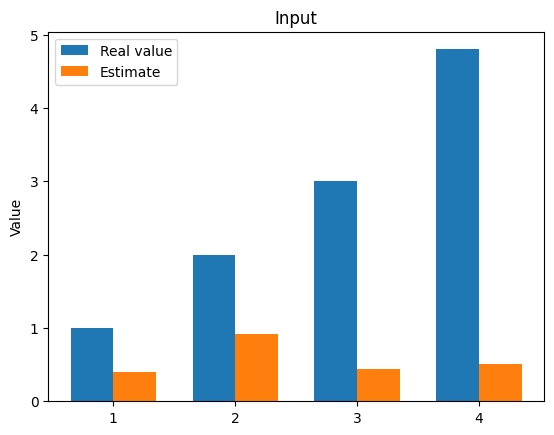

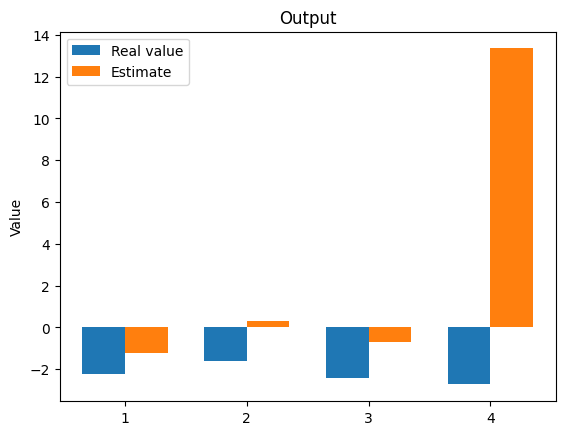

The function inverse_cuqi took 645.7026386260986 seconds.


In [ ]:
sigma=0.5
estimate_MF_adapt=final_model.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,adapt=False, scale=scale)


In [ ]:
for i in range(len(sigma)):
    estimate_MF=final_model.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma[i]**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


ValueError: Scale must be set to sample without adaptation. Consider using sample_adapt instead.

Sample 5000 / 5000

Average acceptance rate: 0.24 MCMC scale: 0.45930641026573926 

********************  # Mean values = [0.53767705 0.64247312 0.57117552 3.25954374]  ********************
Sample 5000 / 5000

Average acceptance rate: 0.23666666666666666 MCMC scale: 0.44878152710426183 

********************  # Mean values = [0.52438231 0.61636141 0.56835818 3.251827  ]  ********************
Sample 5000 / 5000

Average acceptance rate: 0.2733333333333333 MCMC scale: 0.45920655779055564 

********************  # Mean values = [0.54506774 0.59942476 0.57683108 3.18024281]  ********************
Sample 5000 / 5000

Average acceptance rate: 0.236 MCMC scale: 0.4641390073819235 

********************  # Mean values = [0.54480513 0.59293723 0.5712054  3.16123843]  ********************
Sample 4950 / 5000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 5000 / 5000

Average acceptance rate: 0.248 MCMC scale: 0.4705076294471981 

********************  # Mean values = [0.54207112 0.58545343 0.57148498 3.10314416]  ********************
(5, 4, 1500)


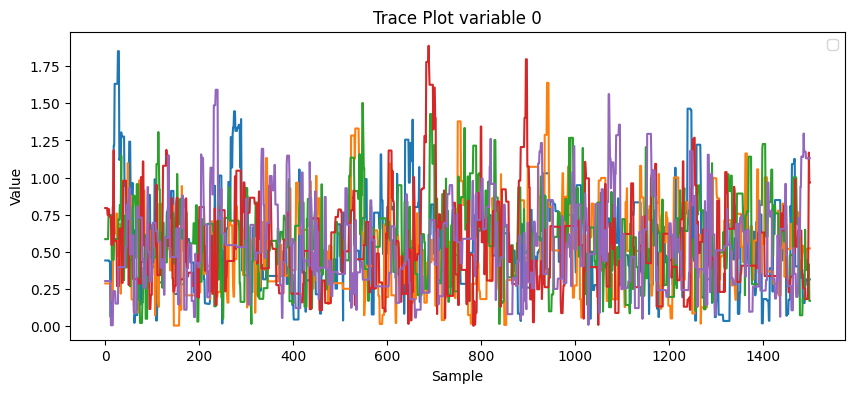

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


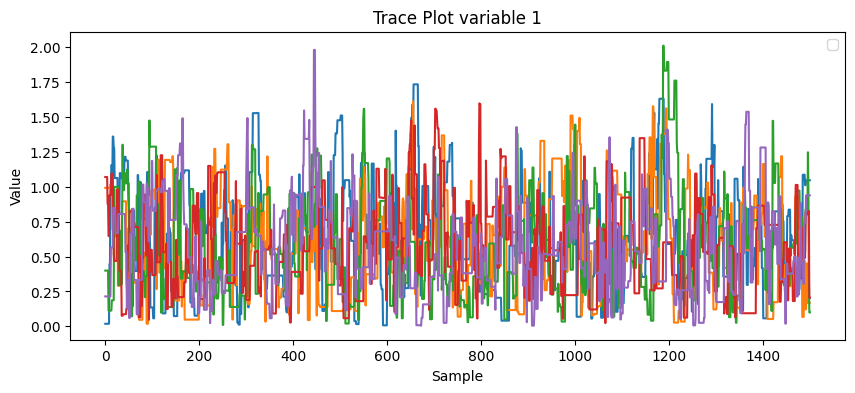

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


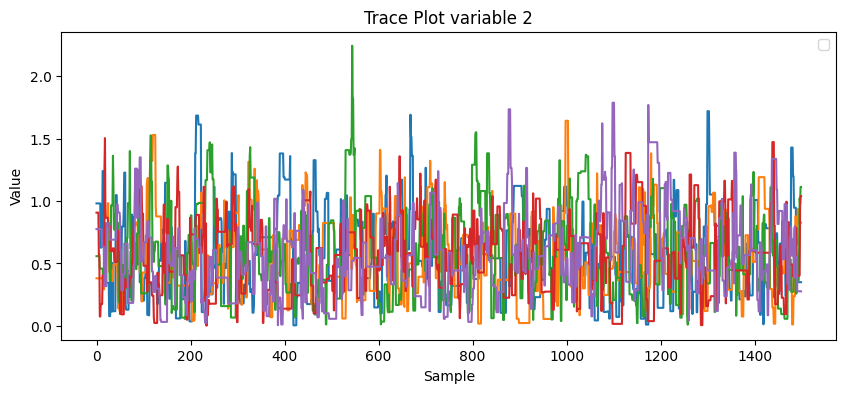

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


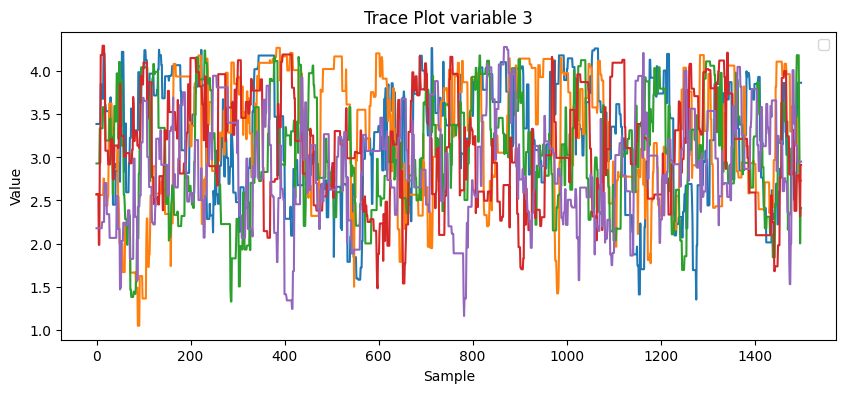

[0.1508     0.20933333 0.28186667 0.32706667 0.3104     0.3332
 0.3224     0.27386667 0.23346667 0.1732     0.12613333 0.09293333
 0.06333333 0.03773333 0.03333333 0.018      0.0104     0.01226667
 0.01106667 0.0148    ]


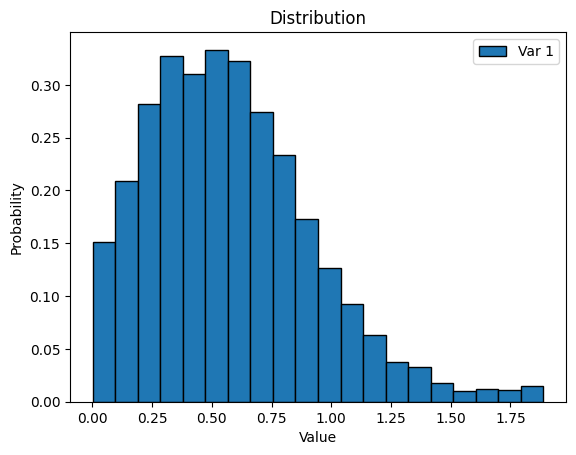

[0.1592     0.23226667 0.3084     0.36333333 0.32653333 0.35
 0.32613333 0.26453333 0.214      0.16333333 0.0988     0.07453333
 0.04866667 0.03226667 0.02133333 0.012      0.01346667 0.0104
 0.01506667 0.01306667]


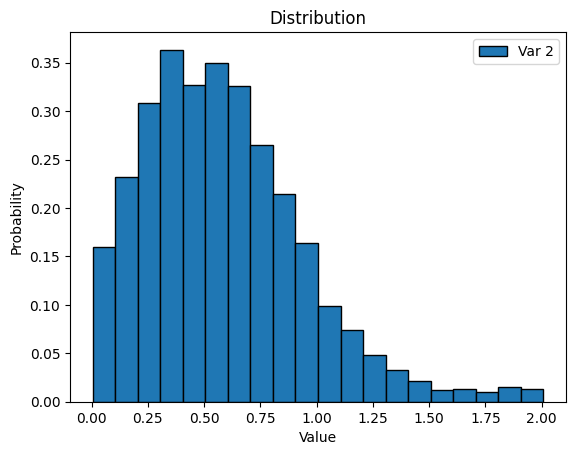

[0.18373333 0.27386667 0.36546667 0.3936     0.37333333 0.38826667
 0.3132     0.24293333 0.1804     0.11       0.076      0.04573333
 0.02733333 0.02053333 0.01306667 0.01346667 0.016      0.01493333
 0.02106667 0.0324    ]


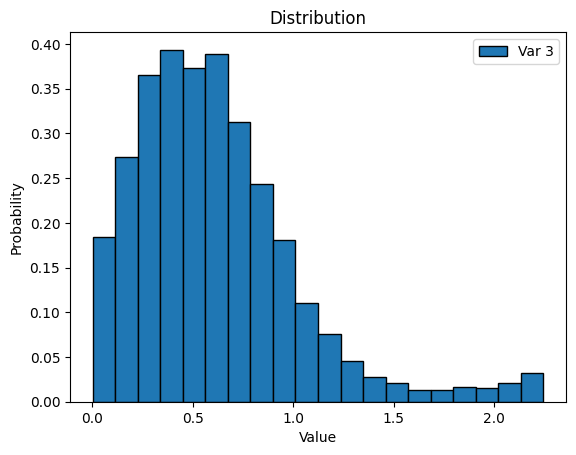

[0.13253333 0.0704     0.03666667 0.01906667 0.01906667 0.02293333
 0.03573333 0.05746667 0.05613333 0.08106667 0.08773333 0.08813333
 0.076      0.08386667 0.06093333 0.05813333 0.06013333 0.0816
 0.08       0.0412    ]


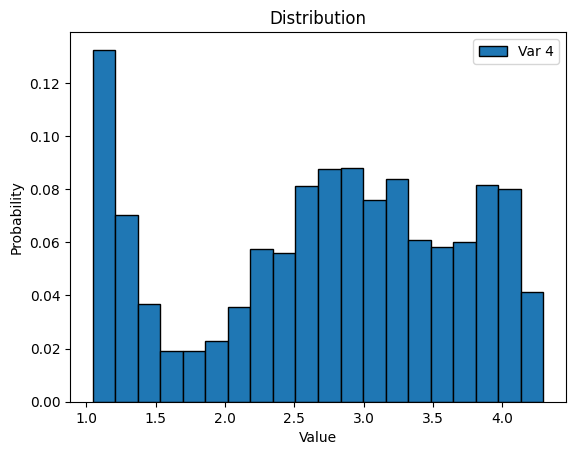

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 611.7901046062798  ********************


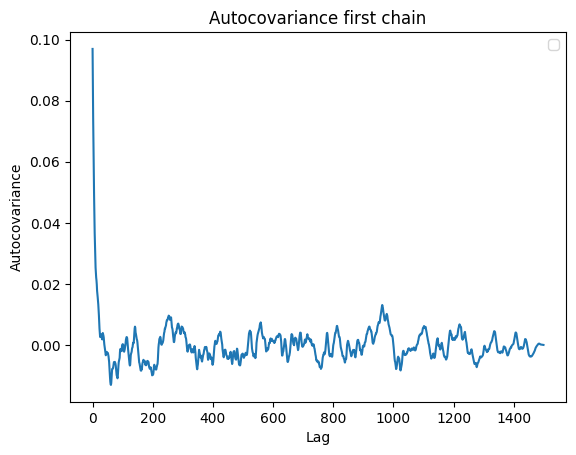

the difference between estimated values [0.04207112 1.41454657 2.42851502 1.39685584]
 the difference between outputs of two models are [0.01673281 3.3287423  5.1978397  6.105451  ]


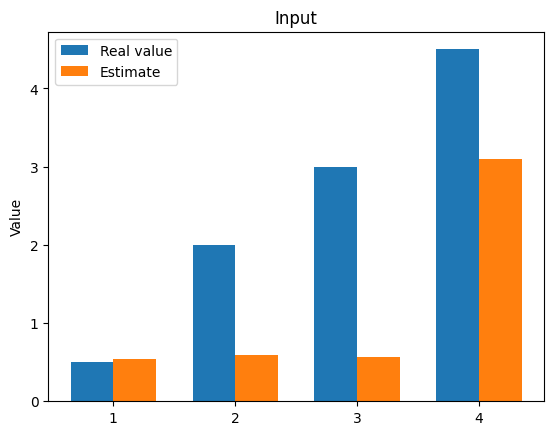

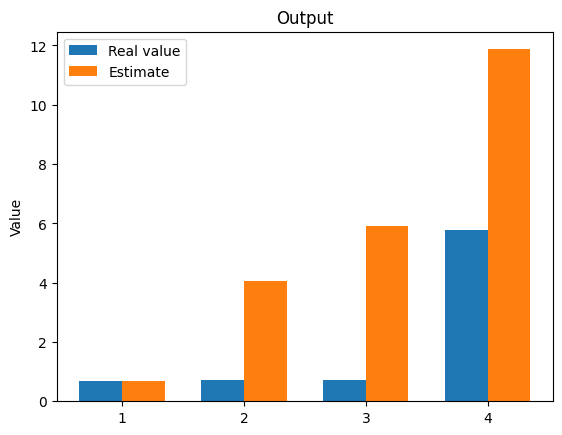

The function inverse_cuqi took 1069.629404783249 seconds.


In [ ]:
estimate_LF=modelLF.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


Sample 5000 / 5000

Average acceptance rate: 0.24133333333333334 MCMC scale: 0.28038019277656123 

********************  # Mean values = [1.74645459 1.89331505 1.2546988  0.1186344 ]  ********************
Sample 5000 / 5000

Average acceptance rate: 0.2633333333333333 MCMC scale: 0.28528815515025435 

********************  # Mean values = [1.62233828 1.91975997 1.48952995 0.11505458]  ********************
Sample 5000 / 5000

Average acceptance rate: 0.2653333333333333 MCMC scale: 0.2749140560718214 

********************  # Mean values = [1.68185653 2.01534302 1.55338852 0.11646174]  ********************
Sample 5000 / 5000

Average acceptance rate: 0.24666666666666667 MCMC scale: 0.2759394392758144 

********************  # Mean values = [1.66476882 1.96001158 1.59450982 0.11819044]  ********************
Sample 4950 / 5000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 5000 / 5000

Average acceptance rate: 0.24133333333333334 MCMC scale: 0.2763553477158791 

********************  # Mean values = [1.64360298 1.9015979  1.55743532 0.11879689]  ********************
(5, 4, 1500)


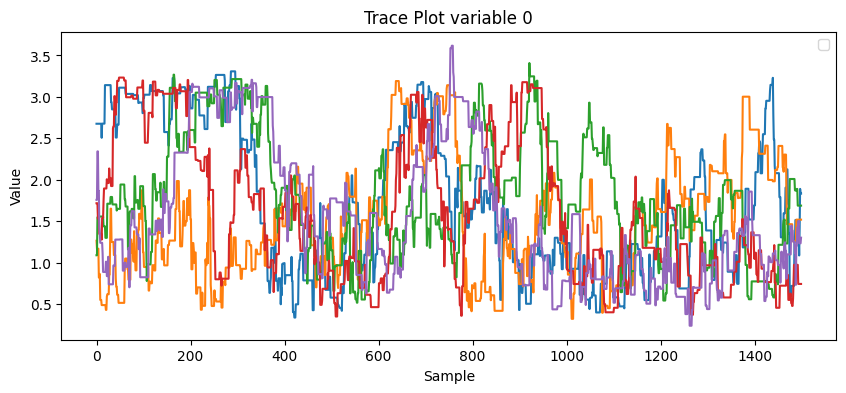

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


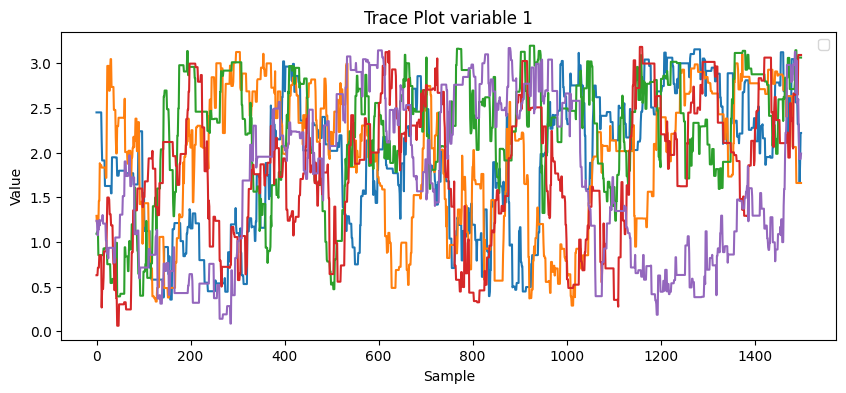

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


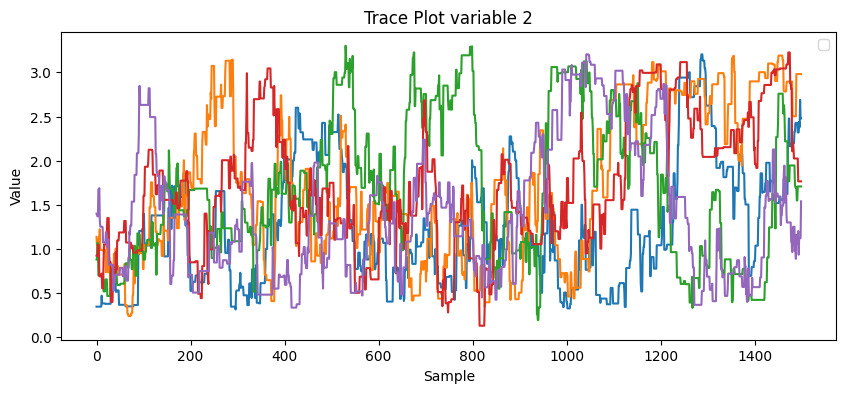

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


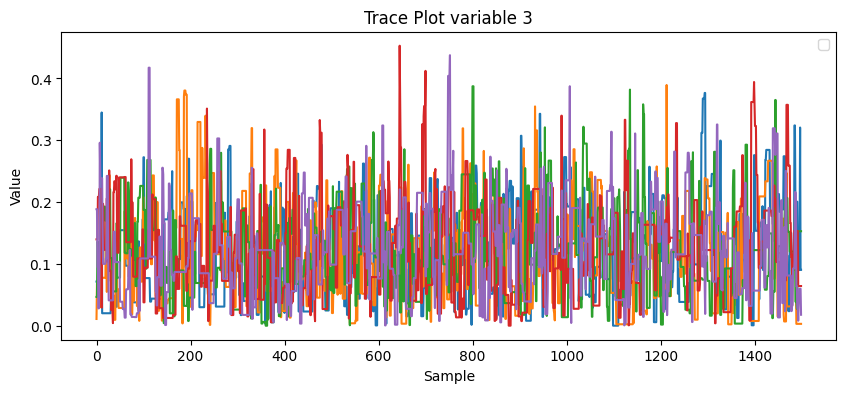

[0.12826667 0.16306667 0.196      0.20306667 0.20226667 0.20613333
 0.20186667 0.18986667 0.2176     0.17453333 0.18266667 0.1456
 0.1496     0.13093333 0.15093333 0.15426667 0.1892     0.07053333
 0.002      0.0008    ]


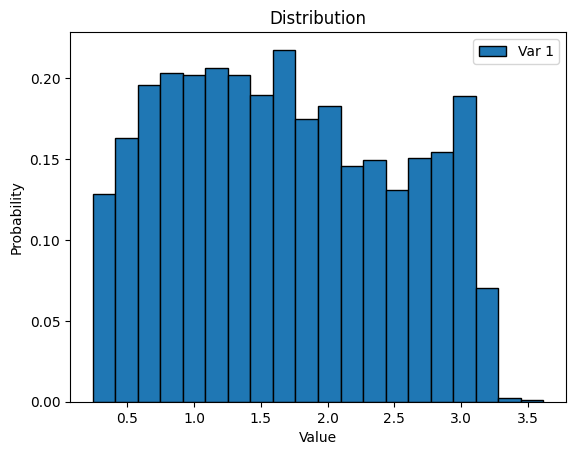

[0.63706667 0.13346667 0.1464     0.1604     0.20346667 0.1904
 0.19       0.19306667 0.17533333 0.1884     0.19746667 0.1516
 0.17186667 0.13986667 0.13813333 0.12173333 0.13466667 0.13586667
 0.18653333 0.11866667]


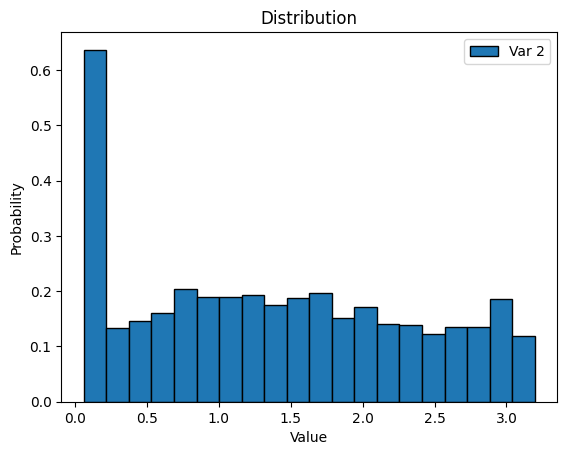

[0.39546667 0.11146667 0.15773333 0.19693333 0.18826667 0.186
 0.19706667 0.19       0.17293333 0.20893333 0.16973333 0.174
 0.152      0.13253333 0.14893333 0.10413333 0.1444     0.14666667
 0.1868     0.038     ]


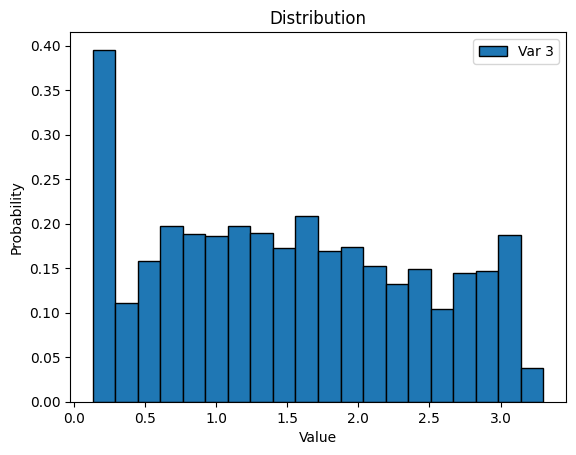

[0.09106667 0.10666667 0.08906667 0.1088     0.10813333 0.11973333
 0.09653333 0.06493333 0.07986667 0.056      0.03946667 0.0184
 0.014      0.00693333 0.0128     0.01266667 0.02333333 0.0204
 0.01893333 0.01813333]


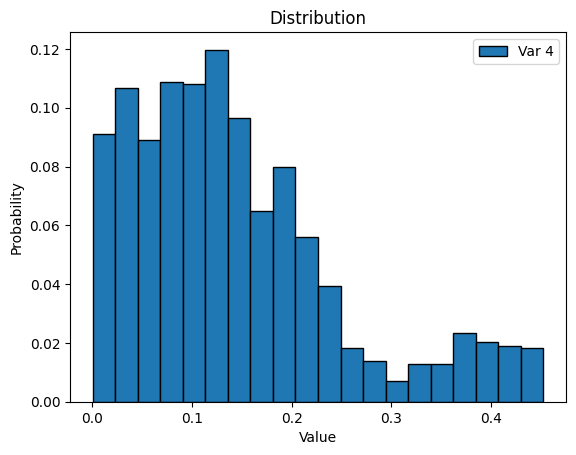

********************  # ESS values = 49.840239647637446  ********************


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


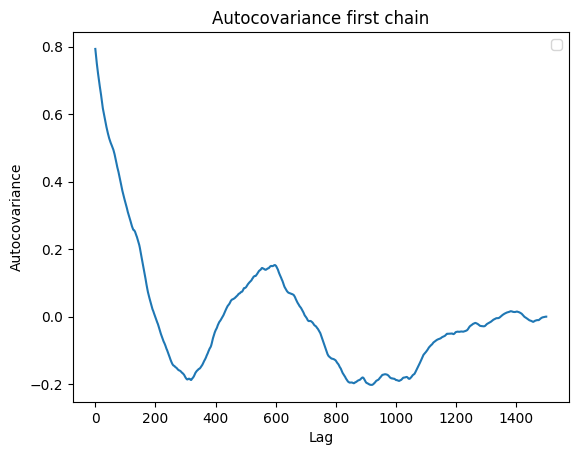

the difference between estimated values [1.14360298 0.0984021  1.44256468 4.38120311]
 the difference between outputs of two models are [ 0.30974454  0.10681516  0.07173431 12.849627  ]


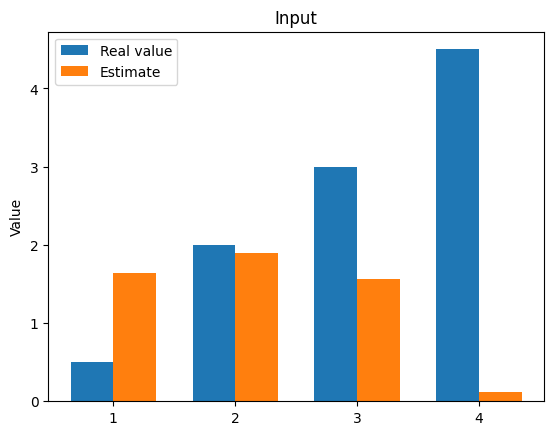

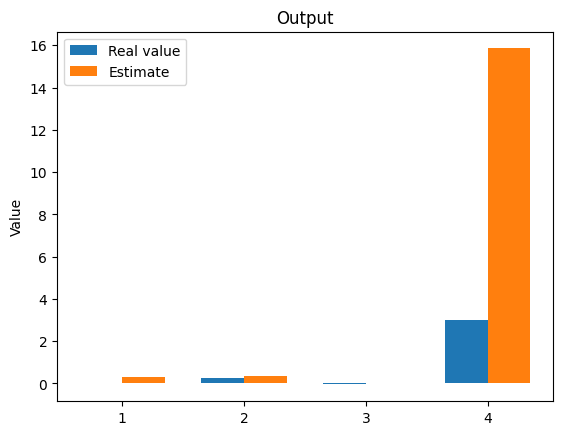

The function inverse_cuqi took 16405.520260810852 seconds.


In [ ]:
estimate_HF=modelHF.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


# MCMC using tinyDA

In [12]:
dim=1
#real_x = np.random.rand(dim)*5
#real_x=np.array([0.5,2.,3.,4.5])
real_x=np.array([1,2,3,4])
# Set parameters for the MCMC

mean_prior = np.ones(dim)
cov_prior = np.ones(dim)*5*0.2
sigma=0.7
sigma_noise=0.1
rwmh_cov = np.eye(dim) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=3

In [13]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [1 2 3 4]
Sampling chain 1/3


Running chain, α = 0.39: 100%|██████████| 2000/2000 [05:11<00:00,  6.42it/s]


Sampling chain 2/3


Running chain, α = 0.32: 100%|██████████| 2000/2000 [05:02<00:00,  6.61it/s]


Sampling chain 3/3


Running chain, α = 0.25: 100%|██████████| 2000/2000 [05:02<00:00,  6.61it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [ ]:
estimate_MF2=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_HF2=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")
estimate_LF2=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

# Multifidelity

real values are [0.5 2.  3.  4.5]
Sampling chain 1/7


Running chain, α = 0.62: 100%|██████████| 3000/3000 [07:07<00:00,  7.02it/s]


Sampling chain 2/7


Running chain, α = 0.71: 100%|██████████| 3000/3000 [07:54<00:00,  6.32it/s]


Sampling chain 3/7


...

Sampling chain 6/7


Running chain, α = 0.40: 100%|██████████| 3000/3000 [07:57<00:00,  6.28it/s]


Sampling chain 7/7


Running chain, α = 0.30: 100%|██████████| 3000/3000 [08:00<00:00,  6.24it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.429 1.258 1.427 2.272]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.429  0.741   0.127    2.769      0.151    0.108      26.0     186.0   
x1  1.258  0.774   0.054    2.603      0.130    0.093      41.0     122.0   
x2  1.427  0.649   0.103    2.457      0.088    0.063      59.0      90.0   
x3  2.272  0.373   1.481    2.771      0.030    0.021     203.0     351.0   

    r_hat  
x0   1.20  
x1   1.13  
x2   1.08  
x3   1.02  
Autocorrelation...
the difference between estimated values [0.929 0.742 1.573 2.228]
 the difference between outputs of two models are [2.81913617 0.50330272 0.82773891 3.56531405]


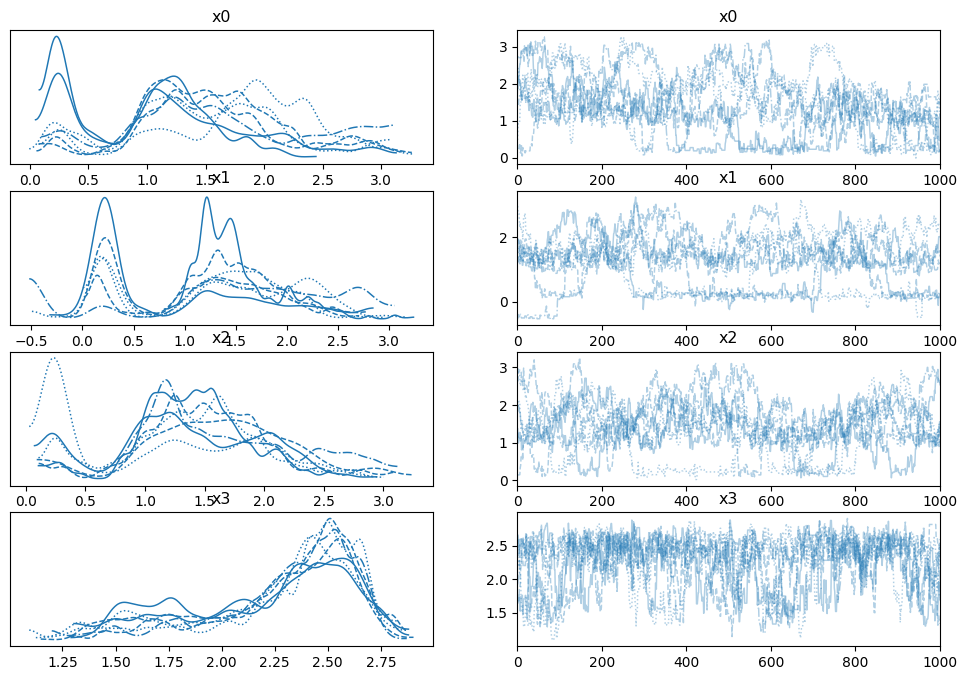

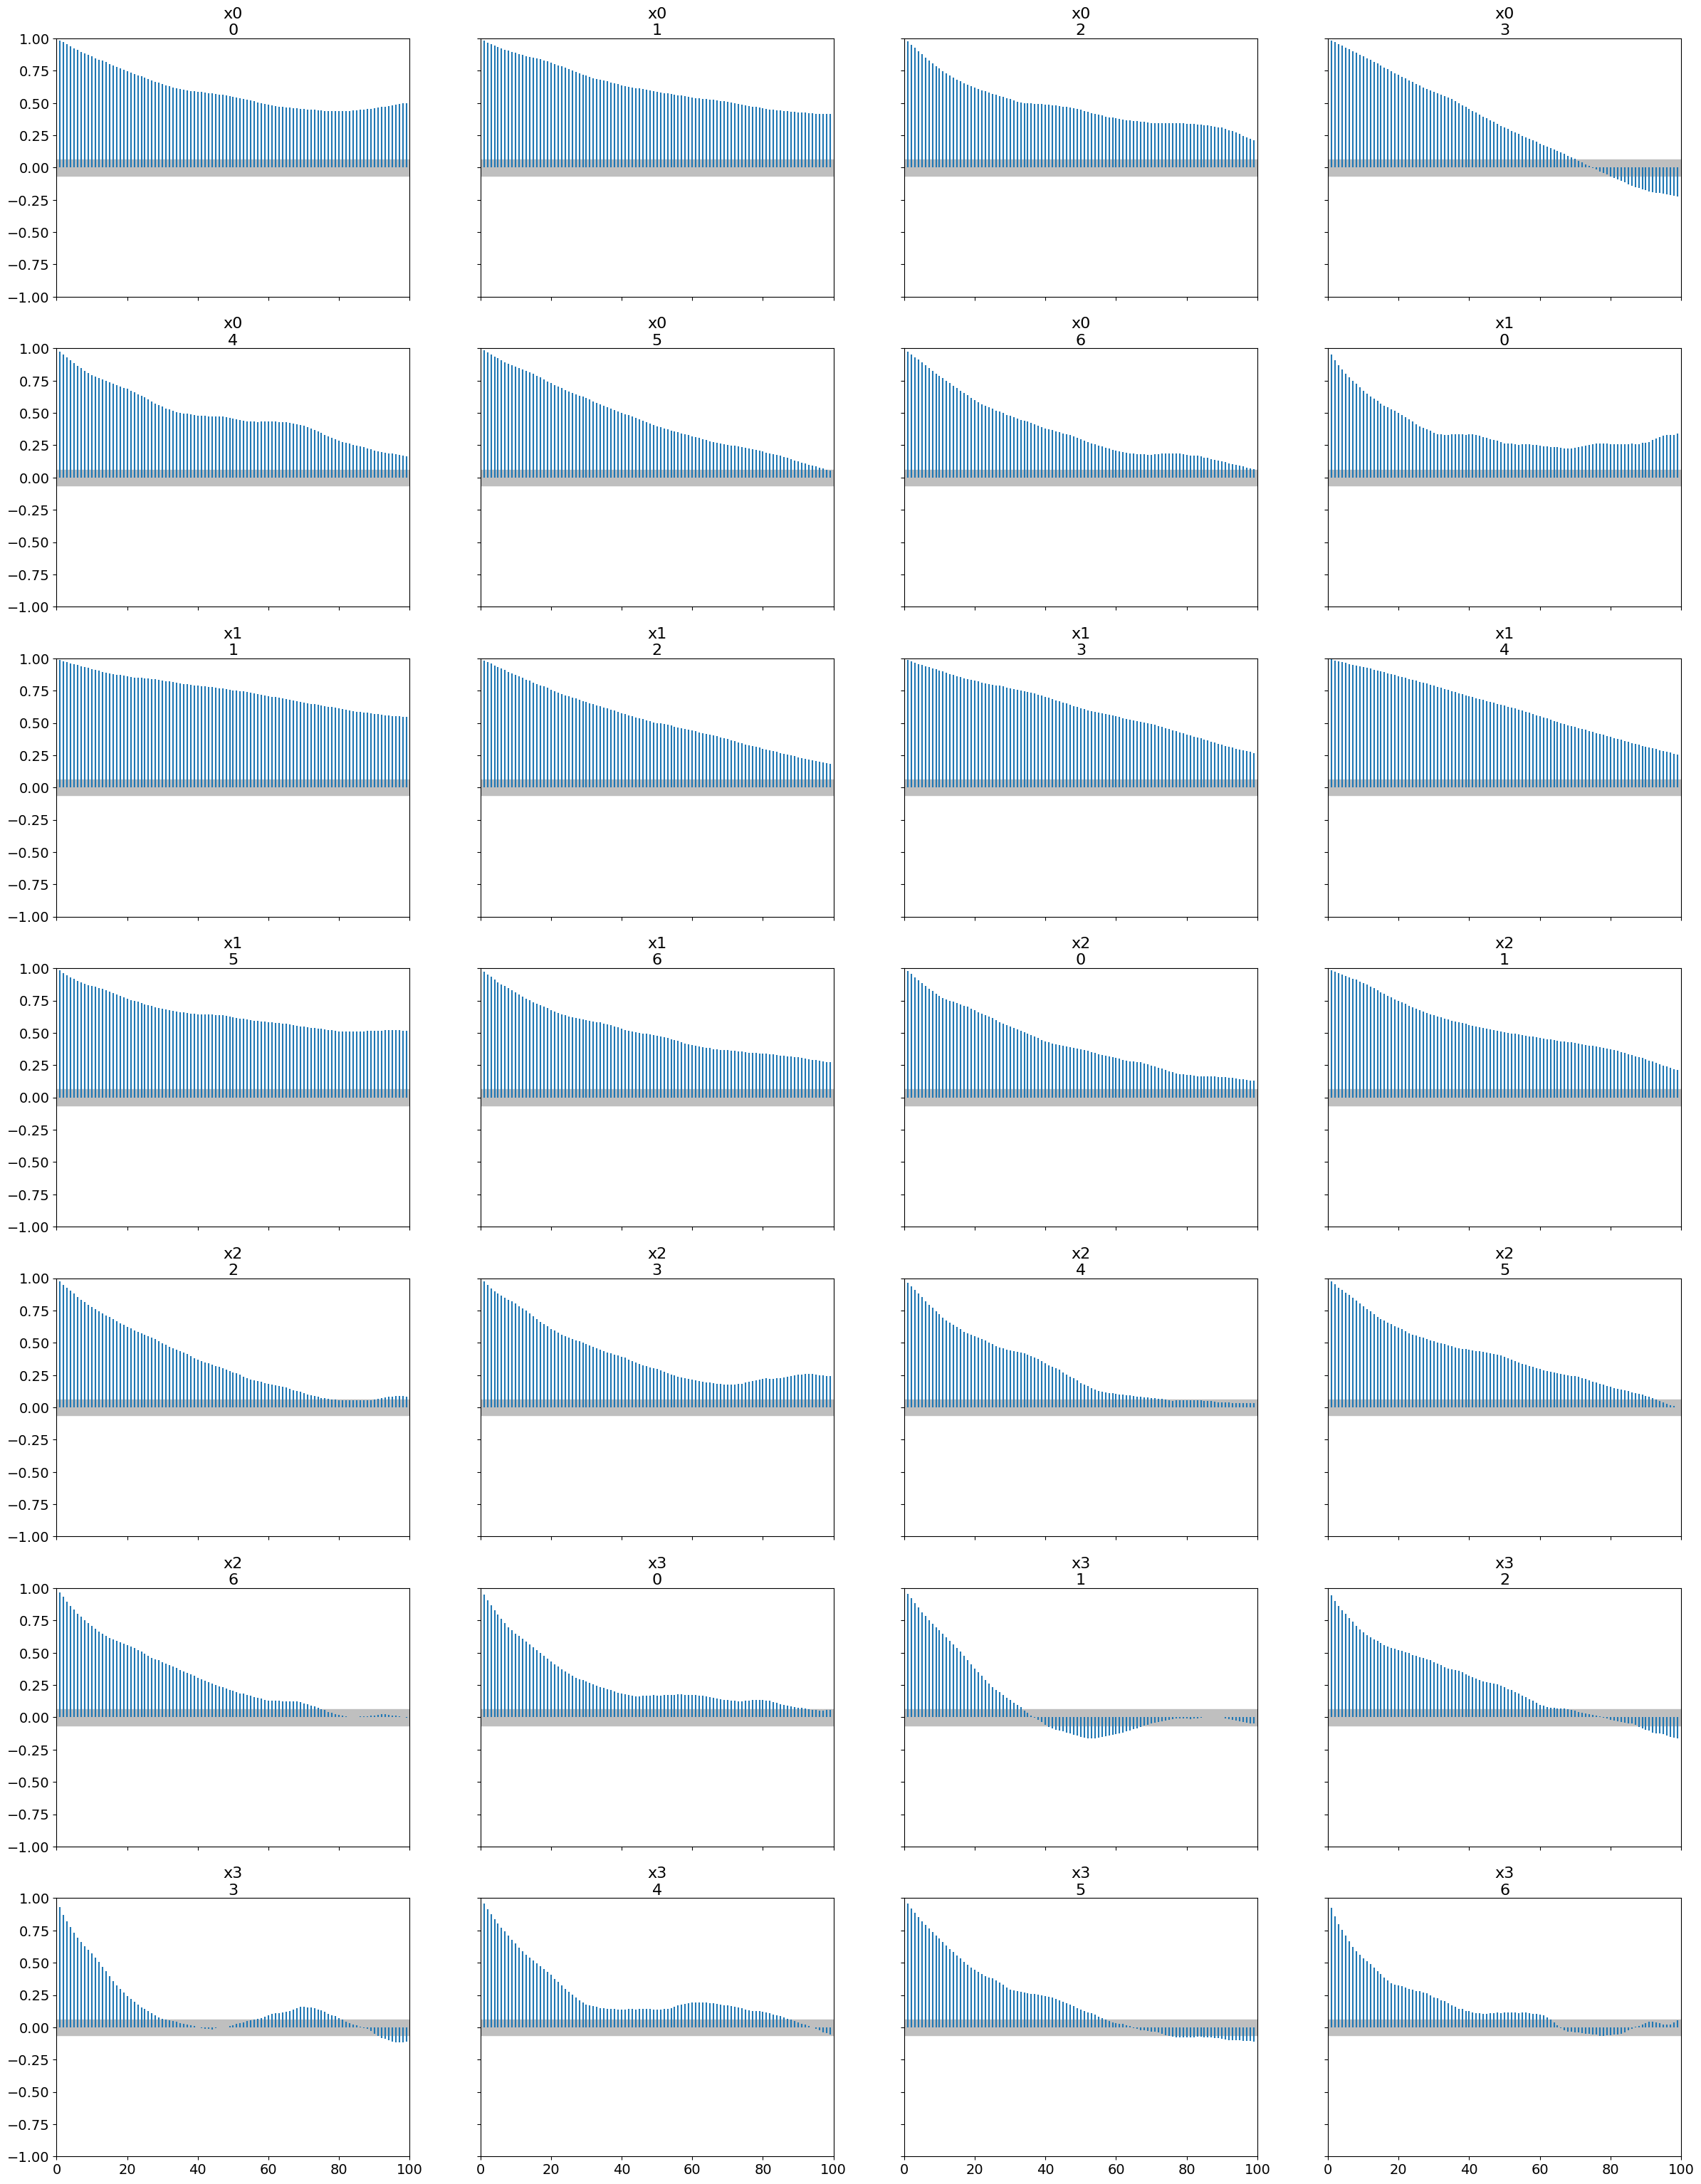

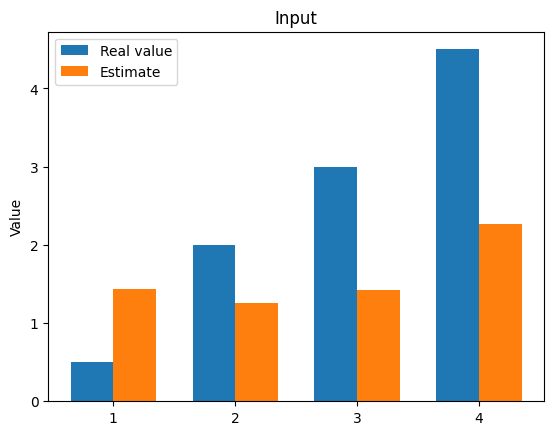

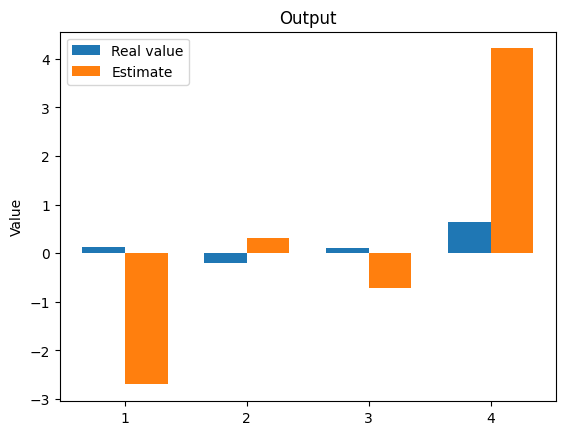

The function inverse took 3335.021594285965 seconds.


In [11]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

real values are [0.5 2.  3.  4.5]
Sampling chain 1/7


Running chain, α = 0.73: 100%|██████████| 3000/3000 [04:05<00:00, 12.21it/s]


Sampling chain 2/7


Running chain, α = 0.61: 100%|██████████| 3000/3000 [04:09<00:00, 12.02it/s]


Sampling chain 3/7


...

Sampling chain 6/7


Running chain, α = 0.71: 100%|██████████| 3000/3000 [04:02<00:00, 12.38it/s]


Sampling chain 7/7


Running chain, α = 0.52: 100%|██████████| 3000/3000 [04:01<00:00, 12.45it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.409 0.489 0.486 2.45 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.409  0.445  -0.555    1.067      0.039    0.028     148.0     249.0   
x1  0.489  0.509  -0.543    1.276      0.042    0.030     149.0     205.0   
x2  0.486  0.449  -0.549    1.118      0.051    0.036      85.0     365.0   
x3  2.450  0.499   1.504    3.451      0.051    0.037     100.0     181.0   

    r_hat  
x0   1.04  
x1   1.02  
x2   1.08  
x3   1.06  
Autocorrelation...
the difference between estimated values [0.091 1.511 2.514 2.05 ]
 the difference between outputs of two models are [0.00857103 3.3811538  5.2378864  6.5590515 ]


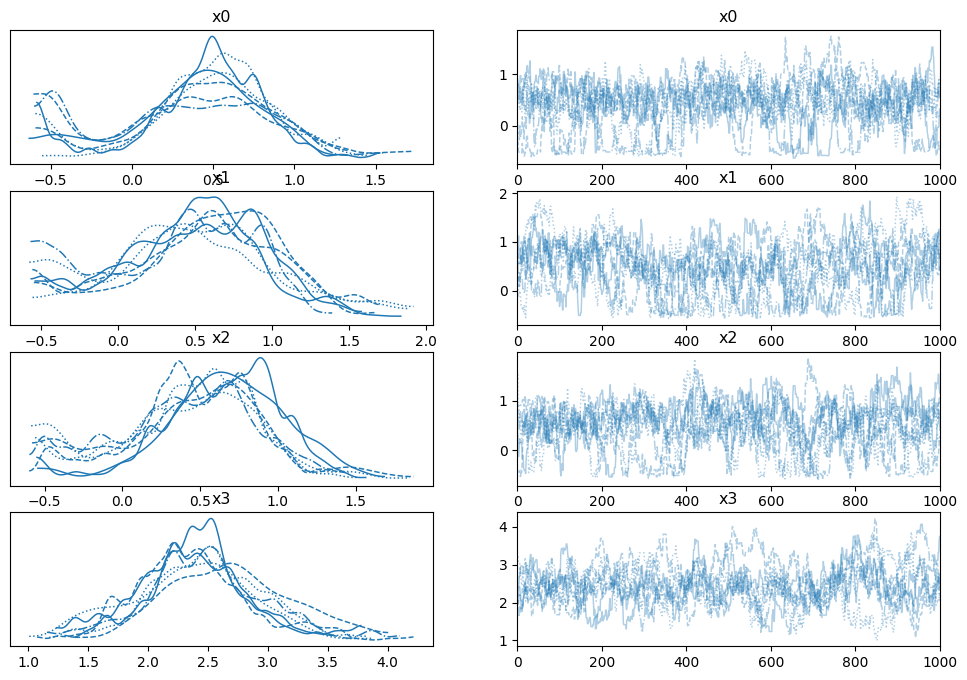

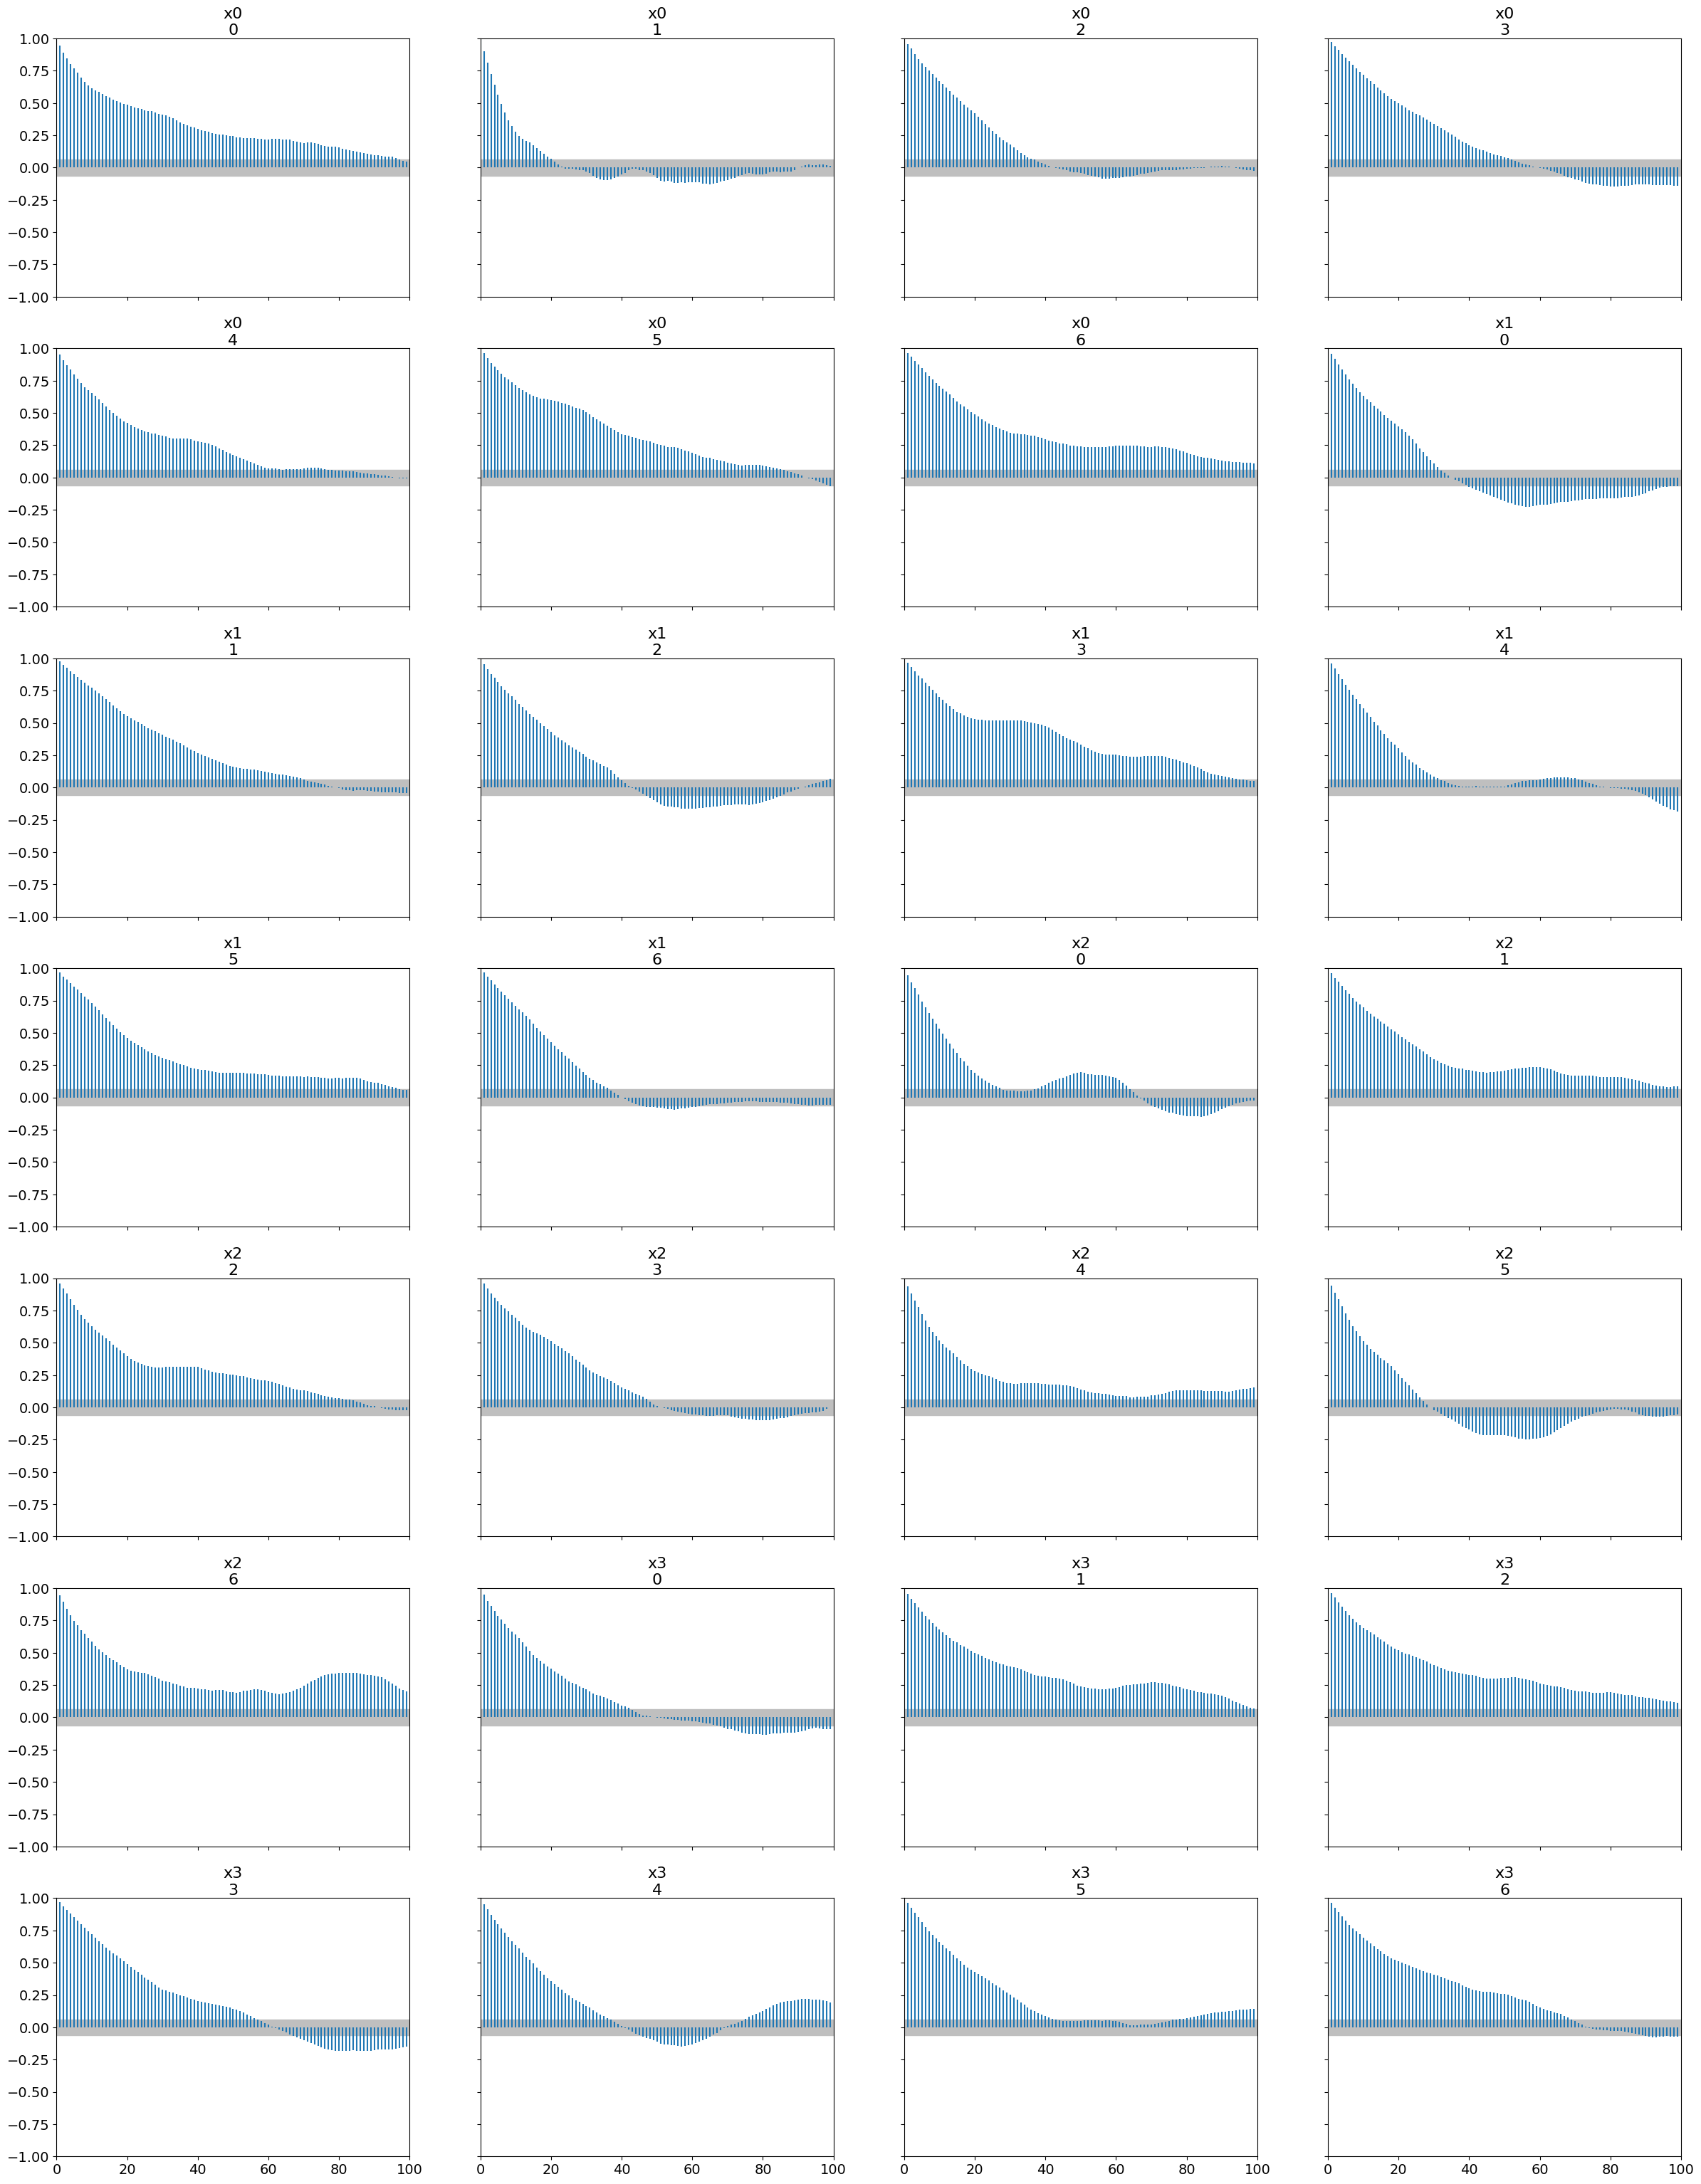

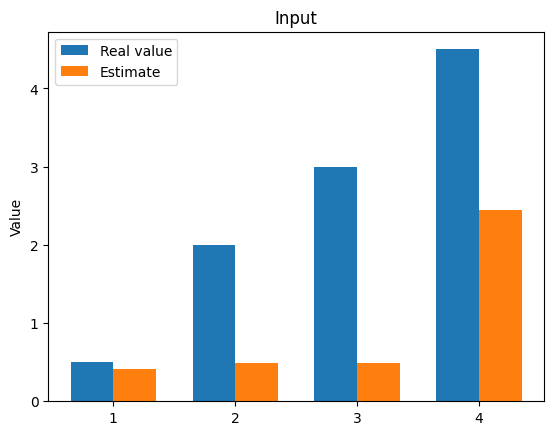

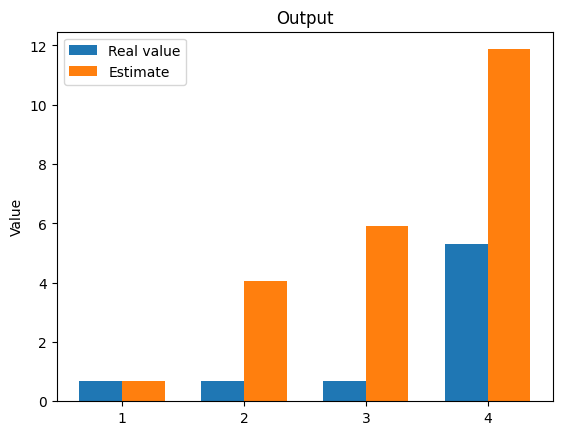

The function inverse took 1729.4988925457 seconds.


In [12]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


## High fidelity


real values are [0.5 2.  3.  4.5]
Sampling chain 1/7


Running chain, α = 0.50: 100%|██████████| 3000/3000 [04:15<00:00, 11.74it/s]


Sampling chain 2/7


Running chain, α = 0.64: 100%|██████████| 3000/3000 [04:16<00:00, 11.71it/s]


Sampling chain 3/7


...

Sampling chain 6/7


Running chain, α = 0.56: 100%|██████████| 3000/3000 [04:11<00:00, 11.91it/s]


Sampling chain 7/7


Running chain, α = 0.57: 100%|██████████| 3000/3000 [04:04<00:00, 12.26it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.192 1.329 1.22  0.021]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.192  0.757  -0.618    2.340      0.163    0.117      27.0      22.0   
x1  1.329  0.804   0.219    3.052      0.147    0.107      32.0      78.0   
x2  1.220  0.751   0.283    3.096      0.171    0.123      20.0      16.0   
x3  0.021  0.146  -0.266    0.268      0.005    0.004     877.0    1155.0   

    r_hat  
x0   1.21  
x1   1.17  
x2   1.27  
x3   1.00  
Autocorrelation...
the difference between estimated values [0.692 0.671 1.78  4.479]
 the difference between outputs of two models are [ 0.557185    0.5313906   0.24707842 12.803985  ]


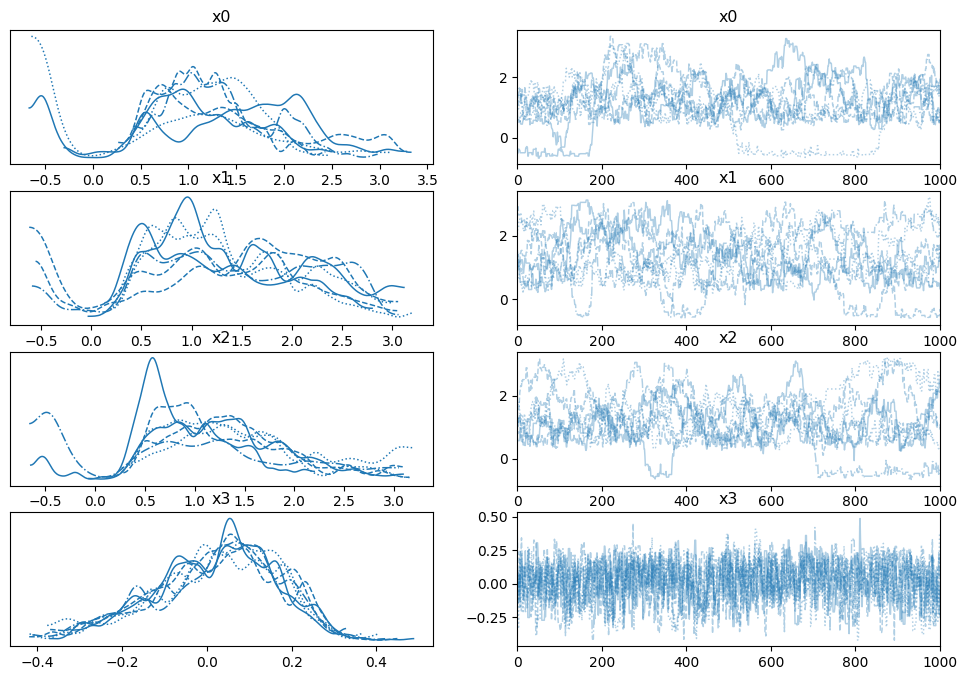

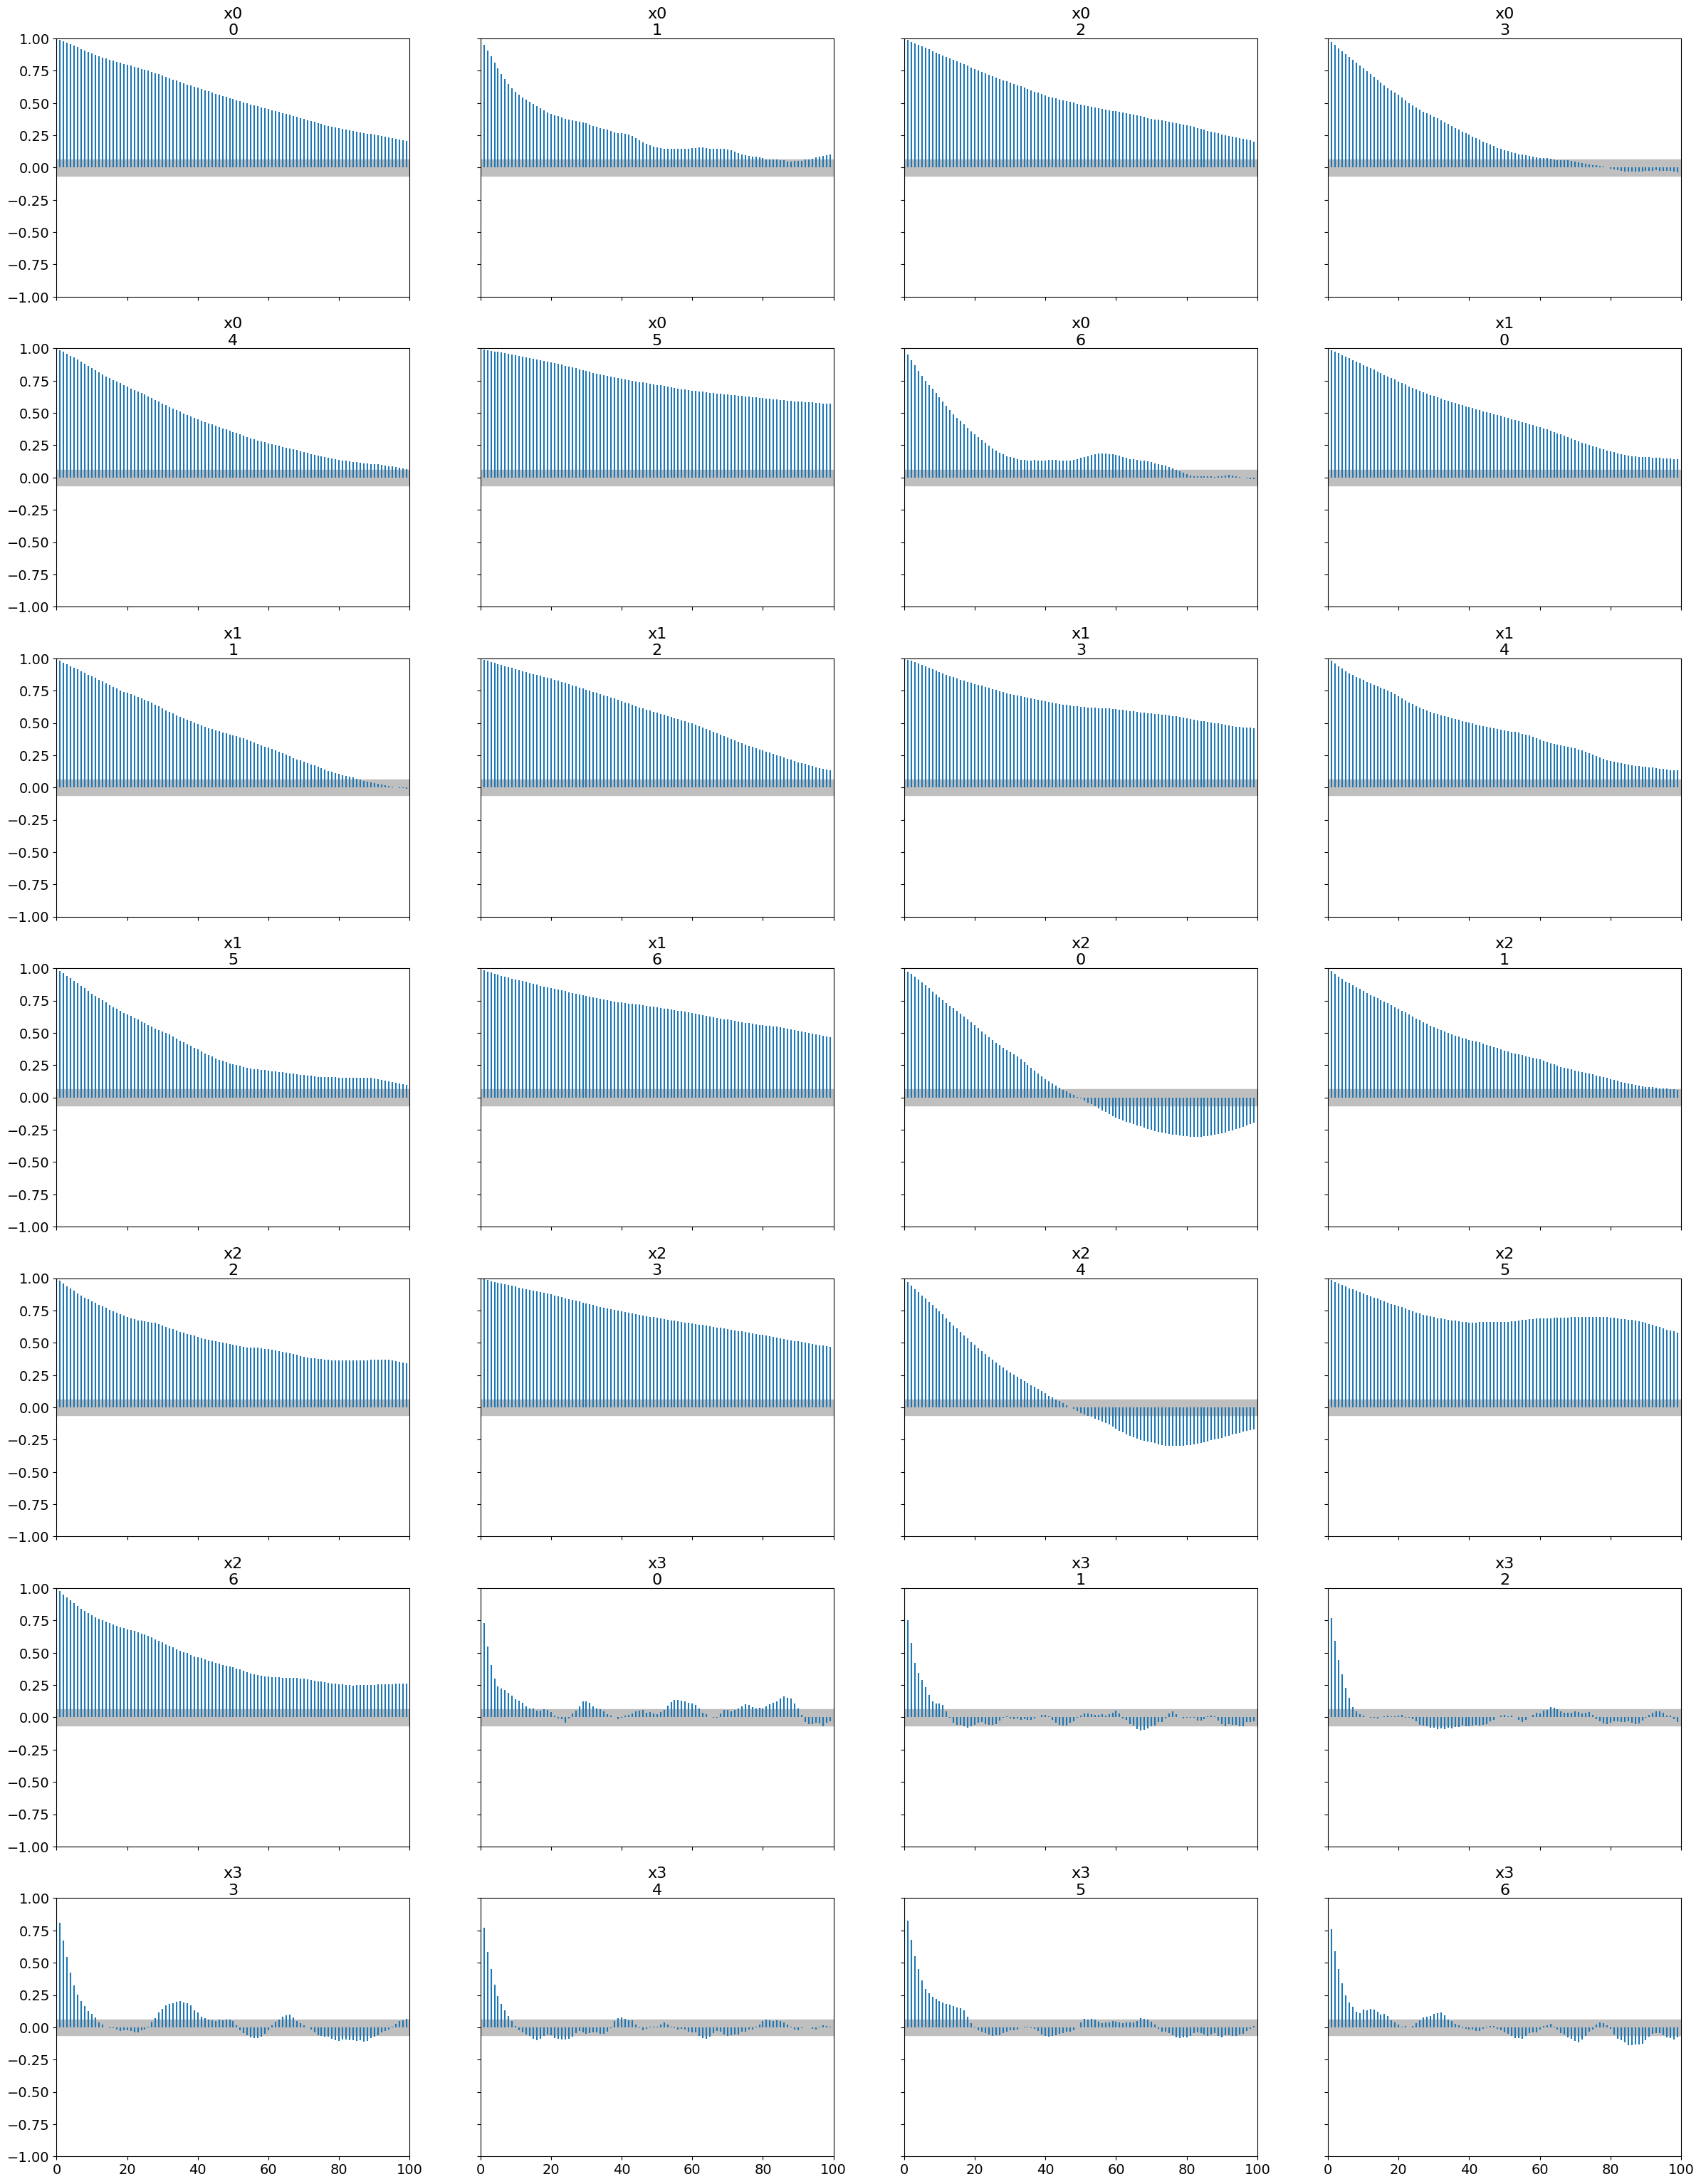

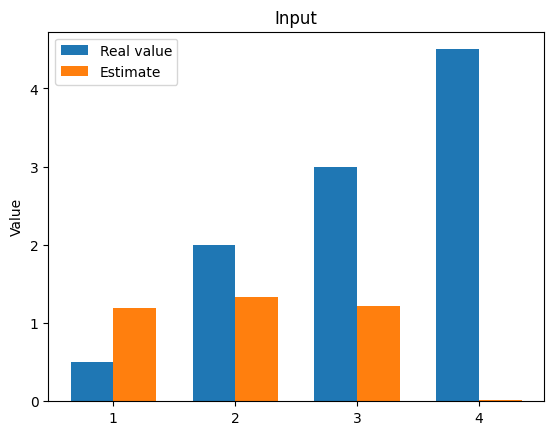

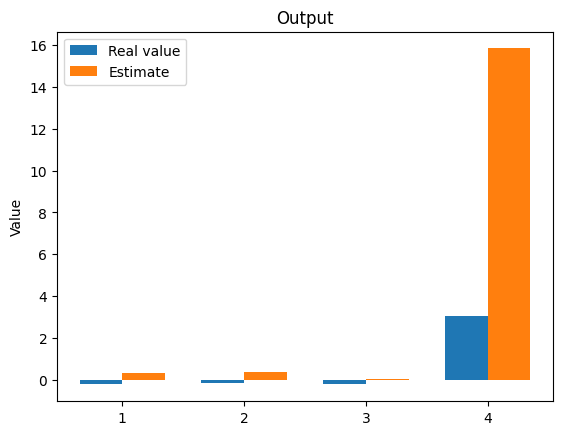

The function inverse took 1798.282480955124 seconds.


In [13]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)